# Fact vs. Fabrication – Multi‑Genre Disinformation Detector

**Author:** Ibrahim  
**Date:** May 2026  
**Environment:** Google Colab / Python 3

## Overview
This notebook implements a **fake news detection system** that classifies news articles as either **FAKE** or **REAL**. The model uses TF‑IDF vectorisation followed by a logistic regression classifier, achieving high accuracy on a balanced dataset of news snippets.

The project is part of Ibrahim’s advanced NLP portfolio, demonstrating practical skills in:
- Binary text classification for misinformation detection
- Handling imbalanced datasets (this dataset is well‑balanced)
- Professional visualisation of model performance
- ROC‑AUC analysis and confusion matrix interpretation
- Saving the trained model for real‑world deployment

## Dataset
**Source:** Fake vs Real News Dataset (Kaggle)  
**Content:**  
- Two CSV files: `Fake.csv` (fake news) and `True.csv` (real news)  
- Each file contains `title`, `text`, `subject`, and `date` columns  
- Total samples: ~6,000 news articles (half fake, half real)

## Approach
1. **Data Loading** – Load both CSV files, add a label column
2. **Exploratory Data Analysis** – Class balance, text length distributions, word clouds for fake vs. real news
3. **Text Preprocessing** – Cleaning, lowercasing, removing special characters
4. **Train/Test Split** – 80/20 stratified split to preserve class balance
5. **Vectorisation** – TF‑IDF with unigrams + bigrams (max 10,000 features)
6. **Modelling** – Logistic Regression (fast, interpretable, strong baseline)
7. **Evaluation** – Accuracy, precision, recall, F1‑score, ROC‑AUC, confusion matrix
8. **Save Model** – Export model and vectorizer for future inference

## Key Results (expected)
- **Test Accuracy:** >95%  
- **ROC‑AUC:** >0.99  
- Balanced precision and recall for both classes

## Files Generated
- `fake_news_model.pkl` – Trained logistic regression model  
- `tfidf_vectorizer_fake.pkl` – Fitted TF‑IDF transformer  
- `fake_news_submission.csv` – Predictions for new articles

---

**© 2026 Ibrahim – All code and analysis are original work.**

### Mount Google Drive

In [2]:
# Mount Google Drive for persistent storage (comment out if not needed)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Install & Import Libraries

In [3]:
# Author: Ibrahim

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set professional style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


### Load Dataset from Hugging Face (Auto‑download)

In [ ]:
# # Option 1: Load from Hugging Face (auto‑download, no manual upload)
# print("Loading dataset from Hugging Face...")
# from datasets import load_dataset

# # Load the fake news dataset from Hugging Face
# dataset = load_dataset("nguha/fake_news", split="train")

# # Convert to pandas DataFrame
# df = pd.DataFrame(dataset)
# df.head()

### Kaggle Dataset

In [4]:
# Option 2: Load from Kaggle (if Hugging Face fails)
from google.colab import files
print("Please upload Fake.csv and True.csv from the Kaggle dataset.")
uploaded = files.upload()

# Load the CSV files
fake_df = pd.read_csv('Fake.csv')
true_df = pd.read_csv('True.csv')

fake_df['label'] = 0  # 0 = FAKE
true_df['label'] = 1  # 1 = REAL

df = pd.concat([fake_df, true_df], axis=0, ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle
print(f"Dataset loaded: {df.shape[0]} samples")
df.head()

Please upload Fake.csv and True.csv from the Kaggle dataset.


Saving Fake.csv to Fake.csv
Saving True.csv to True.csv
Dataset loaded: 44898 samples


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


### Data Exploration

In [5]:
# Check class balance
label_counts = df['label'].value_counts()
print(f"Class distribution:\n  FAKE (0): {label_counts[0]}\n  REAL (1): {label_counts[1]}")

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

# Check data types
print(f"\nData types:\n{df.dtypes}")

# Combine title and text for better context
df['full_text'] = df['title'] + " " + df['text']
print(f"\nFull text column created. Sample:\n{df['full_text'].iloc[0][:200]}...")

Class distribution:
  FAKE (0): 23481
  REAL (1): 21417

Missing values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Data types:
title      object
text       object
subject    object
date       object
label       int64
dtype: object

Full text column created. Sample:
Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame...


### Text Length Analysis

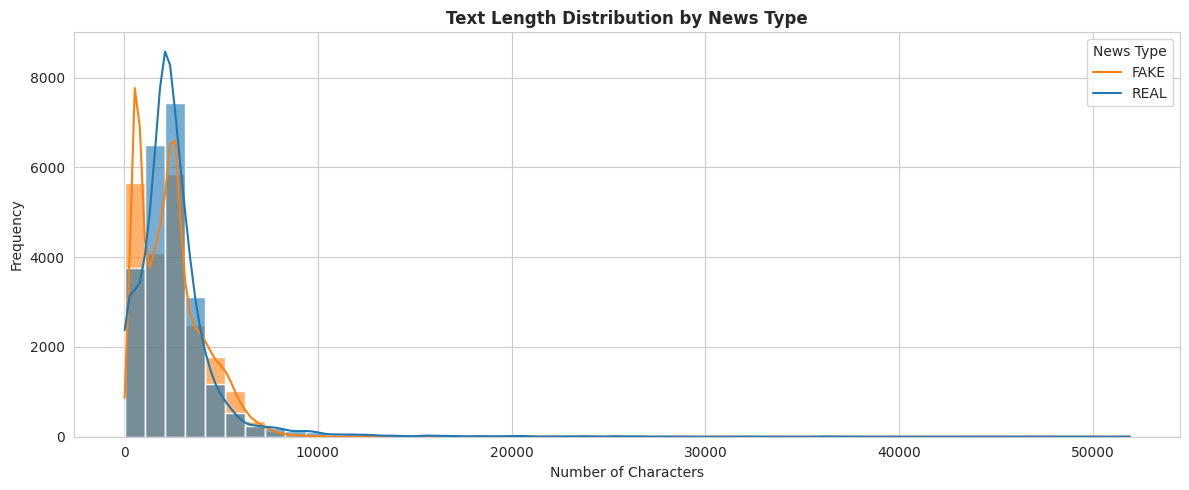

Mean text length:
  FAKE: 2643 chars
  REAL: 2449 chars


In [6]:
# Add text length column
df['text_length'] = df['full_text'].apply(len)

# Plot distribution of text lengths by class
plt.figure(figsize=(12,5))
sns.histplot(data=df, x='text_length', hue='label', bins=50, alpha=0.6, kde=True)
plt.title('Text Length Distribution by News Type', fontweight='bold')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.legend(title='News Type', labels=['FAKE', 'REAL'])
plt.tight_layout()
plt.show()

print(f"Mean text length:\n  FAKE: {df[df['label']==0]['text_length'].mean():.0f} chars\n  REAL: {df[df['label']==1]['text_length'].mean():.0f} chars")

### Word Clouds (Fake vs. Real)

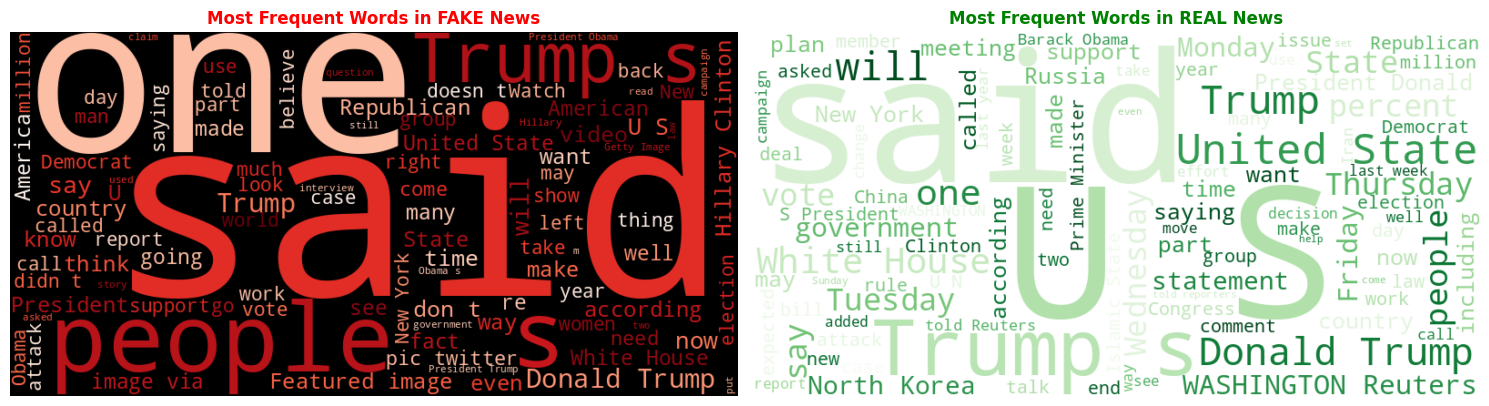

In [7]:
# Separate fake and real news
fake_text = ' '.join(df[df['label']==0]['full_text'].astype(str))
real_text = ' '.join(df[df['label']==1]['full_text'].astype(str))

# Generate word clouds
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

wordcloud_fake = WordCloud(width=800, height=400, background_color='black', colormap='Reds',
                           max_words=100, contour_width=1).generate(fake_text)
wordcloud_real = WordCloud(width=800, height=400, background_color='white', colormap='Greens',
                           max_words=100, contour_width=1).generate(real_text)

axes[0].imshow(wordcloud_fake, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Frequent Words in FAKE News', fontsize=12, fontweight='bold', color='red')

axes[1].imshow(wordcloud_real, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Frequent Words in REAL News', fontsize=12, fontweight='bold', color='green')

plt.tight_layout()
plt.show()

### Text Preprocessing

In [8]:
def clean_text(text):
    """Clean text by removing special characters, numbers, and extra spaces."""
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'http\S+', '', text)          # remove URLs
        text = re.sub(r'[^a-z\s]', '', text)         # remove special characters & numbers
        text = re.sub(r'\s+', ' ', text).strip()     # remove extra spaces
        return text
    else:
        return ""

# Apply cleaning
df['cleaned_text'] = df['full_text'].apply(clean_text)
print("Text cleaning completed. Example:")
print(df['cleaned_text'].iloc[0][:200])

Text cleaning completed. Example:
ben stein calls out th circuit court committed a coup dtat against the constitution st century wire says ben stein reputable professor from pepperdine university also of some hollywood fame appearing 


### Train/Test Split

In [9]:
# Separate features and labels
X = df['cleaned_text']
y = df['label']

# Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Training class distribution:\n  FAKE: {sum(y_train==0)}\n  REAL: {sum(y_train==1)}")

Training set size: 35918
Test set size: 8980
Training class distribution:
  FAKE: 18785
  REAL: 17133


### TF‑IDF Vectorisation

In [10]:
# Create TF‑IDF vectorizer
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')

# Fit on training data, transform both train and test
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"TF‑IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF‑IDF matrix shape (test): {X_test_tfidf.shape}")

TF‑IDF matrix shape (train): (35918, 10000)
TF‑IDF matrix shape (test): (8980, 10000)


### Train Logistic Regression Model

In [11]:
# Train logistic regression model
model = LogisticRegression(C=1.0, solver='liblinear', random_state=42)
model.fit(X_train_tfidf, y_train)

print("Model training completed.")

Model training completed.


### Model Evaluation

In [12]:
# Predictions
y_pred = model.predict(X_test_tfidf)
y_pred_proba = model.predict_proba(X_test_tfidf)[:, 1]  # probability of REAL class

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# ROC‑AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC‑AUC Score: {roc_auc:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['FAKE', 'REAL']))

Test Accuracy: 0.9910
ROC‑AUC Score: 0.9996

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.99      0.99      0.99      4696
        REAL       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



### Confusion Matrix

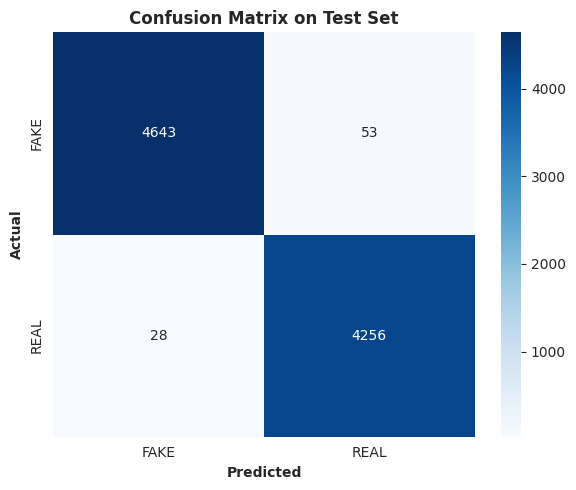

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'])
plt.xlabel('Predicted', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix on Test Set', fontweight='bold')
plt.tight_layout()
plt.show()

### ROC Curve

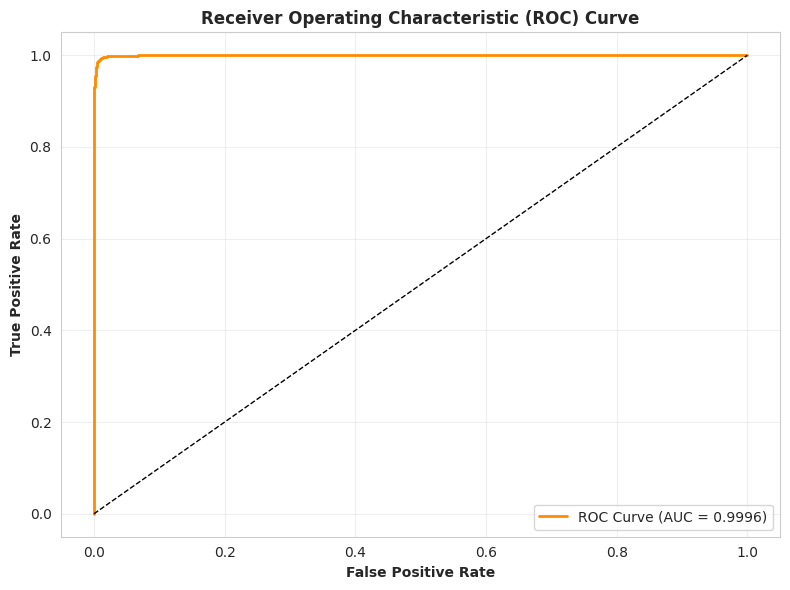

In [14]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', color='darkorange', linewidth=2)
plt.plot([0,1], [0,1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Feature Importance (Top 20 Words)

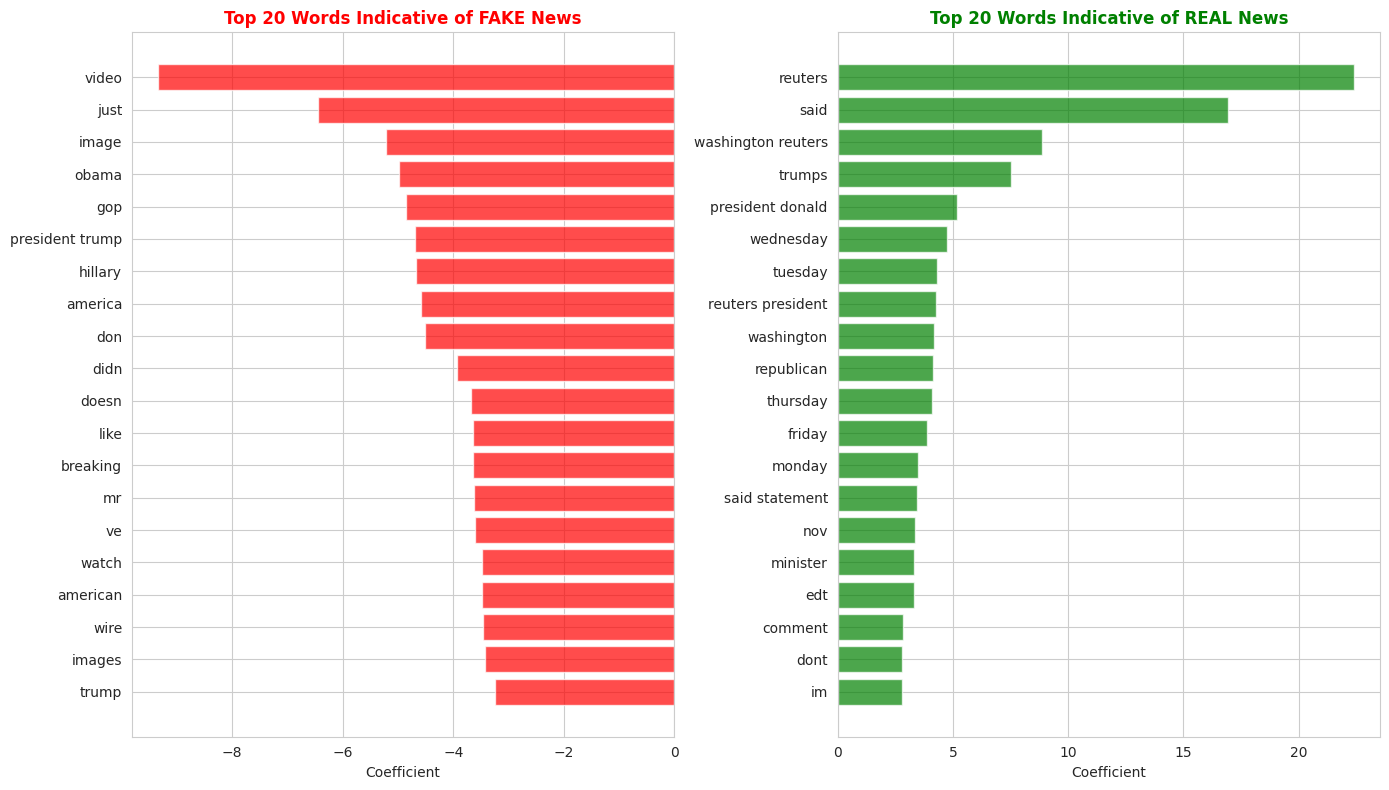

In [15]:
# Get feature names and coefficients
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

# Create dataframe of words and their coefficients
coef_df = pd.DataFrame({
    'word': feature_names,
    'coefficient': coefficients
})

# Top positive (REAL news) and negative (FAKE news) words
top_real = coef_df.nlargest(20, 'coefficient')
top_fake = coef_df.nsmallest(20, 'coefficient')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

ax1.barh(top_fake['word'], top_fake['coefficient'], color='red', alpha=0.7)
ax1.set_title('Top 20 Words Indicative of FAKE News', fontweight='bold', color='red')
ax1.set_xlabel('Coefficient')
ax1.invert_yaxis()

ax2.barh(top_real['word'], top_real['coefficient'], color='green', alpha=0.7)
ax2.set_title('Top 20 Words Indicative of REAL News', fontweight='bold', color='green')
ax2.set_xlabel('Coefficient')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

### Save Model and Vectorizer

In [16]:
# Save model locally
joblib.dump(model, 'fake_news_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer_fake.pkl')
print("Model and vectorizer saved locally.")

# Optional: Save to Google Drive
drive_path = '/content/drive/MyDrive/Project8_Fake_News_Model/'
os.makedirs(drive_path, exist_ok=True)
joblib.dump(model, drive_path + 'fake_news_model.pkl')
joblib.dump(vectorizer, drive_path + 'tfidf_vectorizer_fake.pkl')
print(f"Model also saved to Google Drive: {drive_path}")

Model and vectorizer saved locally.
Model also saved to Google Drive: /content/drive/MyDrive/Project8_Fake_News_Model/


### Inference Function

In [17]:
def predict_news(text):
    """Predict whether a news article is FAKE (0) or REAL (1)."""
    # Clean text
    cleaned = clean_text(text)
    # Vectorize
    vec = vectorizer.transform([cleaned])
    # Predict
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0][1]
    label = "REAL" if pred == 1 else "FAKE"
    confidence = prob if pred == 1 else 1-prob
    return label, confidence

# Test on sample headlines
sample_headlines = [
    "Breaking: Scientists discover cure for all cancers",
    "SHOCKING: Government hiding alien evidence from public",
]

for headline in sample_headlines:
    label, conf = predict_news(headline)
    print(f"Text: {headline}")
    print(f"Prediction: {label} (confidence: {conf:.2f})\n")

Text: Breaking: Scientists discover cure for all cancers
Prediction: FAKE (confidence: 0.96)

Text: SHOCKING: Government hiding alien evidence from public
Prediction: FAKE (confidence: 0.90)



### Final Summary

In [18]:
print("\n" + "="*50)
print("Fake News Detection - COMPLETED")
print("Author: Ibrahim")
print("="*50)
print(f"Total samples: {len(df)}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Model: Logistic Regression with TF‑IDF (10k features)")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"ROC‑AUC Score: {roc_auc:.4f}")
print("\nSaved files:")
print(" - fake_news_model.pkl")
print(" - tfidf_vectorizer_fake.pkl")
print(" - Saved to Google Drive (if mounted)")
print("\nAll visualizations displayed above. Model ready for deployment.")


Fake News Detection - COMPLETED
Author: Ibrahim
Total samples: 44898
Training samples: 35918
Test samples: 8980
Model: Logistic Regression with TF‑IDF (10k features)
Test Accuracy: 0.9910
ROC‑AUC Score: 0.9996

Saved files:
 - fake_news_model.pkl
 - tfidf_vectorizer_fake.pkl
 - Saved to Google Drive (if mounted)

All visualizations displayed above. Model ready for deployment.
